In [1]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 12.6 MB/s eta 0:00:00


In [2]:
!pip install torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 5.3 MB/s eta 0:00:00


In [3]:
import torch
import torchmetrics
import torch.nn as nn
import torchvision.transforms.v2 as T
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from sklearn.datasets import load_sample_images

In [5]:
response = load_sample_images()

In [6]:
response.keys()

dict_keys(['images', 'filenames', 'DESCR'])

In [7]:
sample_images = response['images']

In [8]:
sample_images

[array([[[174, 201, 231],
         [174, 201, 231],
         [174, 201, 231],
         ...,
         [250, 251, 255],
         [250, 251, 255],
         [250, 251, 255]],
 
        [[172, 199, 229],
         [173, 200, 230],
         [173, 200, 230],
         ...,
         [251, 252, 255],
         [251, 252, 255],
         [251, 252, 255]],
 
        [[174, 201, 231],
         [174, 201, 231],
         [174, 201, 231],
         ...,
         [252, 253, 255],
         [252, 253, 255],
         [252, 253, 255]],
 
        ...,
 
        [[ 88,  80,   7],
         [147, 138,  69],
         [122, 116,  38],
         ...,
         [ 39,  42,  33],
         [  8,  14,   2],
         [  6,  12,   0]],
 
        [[122, 112,  41],
         [129, 120,  53],
         [118, 112,  36],
         ...,
         [  9,  12,   3],
         [  9,  15,   3],
         [ 16,  24,   9]],
 
        [[116, 103,  35],
         [104,  93,  31],
         [108, 102,  28],
         ...,
         [ 43,  49,  39],
  

array([[[174, 201, 231],
        [174, 201, 231],
        [174, 201, 231],
        ...,
        [250, 251, 255],
        [250, 251, 255],
        [250, 251, 255]],

       [[172, 199, 229],
        [173, 200, 230],
        [173, 200, 230],
        ...,
        [251, 252, 255],
        [251, 252, 255],
        [251, 252, 255]],

       [[174, 201, 231],
        [174, 201, 231],
        [174, 201, 231],
        ...,
        [252, 253, 255],
        [252, 253, 255],
        [252, 253, 255]],

       ...,

       [[ 88,  80,   7],
        [147, 138,  69],
        [122, 116,  38],
        ...,
        [ 39,  42,  33],
        [  8,  14,   2],
        [  6,  12,   0]],

       [[122, 112,  41],
        [129, 120,  53],
        [118, 112,  36],
        ...,
        [  9,  12,   3],
        [  9,  15,   3],
        [ 16,  24,   9]],

       [[116, 103,  35],
        [104,  93,  31],
        [108, 102,  28],
        ...,
        [ 43,  49,  39],
        [ 13,  21,   6],
        [ 15,  24,   7]]], dtype=uint8)
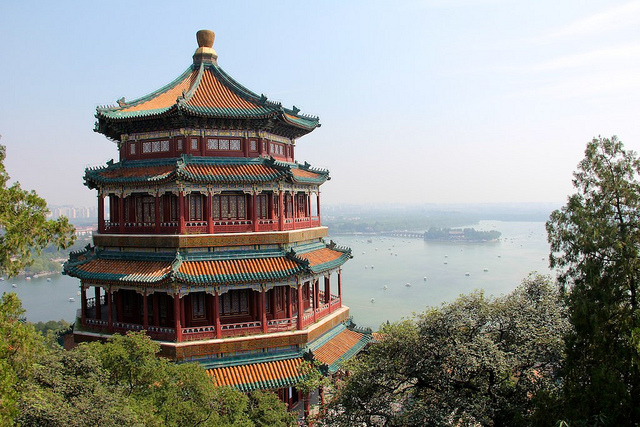

In [9]:
sample_images[0]

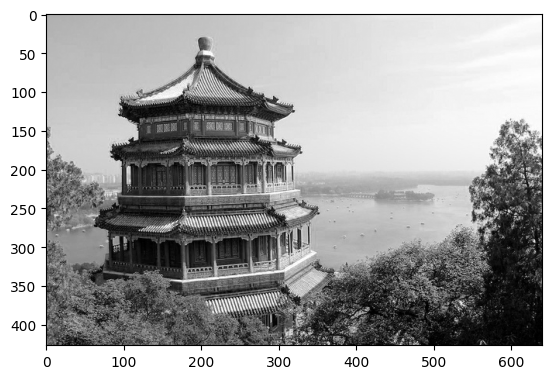

In [10]:
plt.imshow(sample_images[0][:,:,0],cmap='gray')

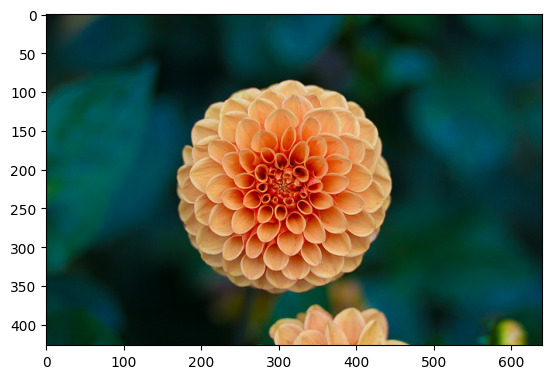

In [11]:
plt.imshow(sample_images[1])

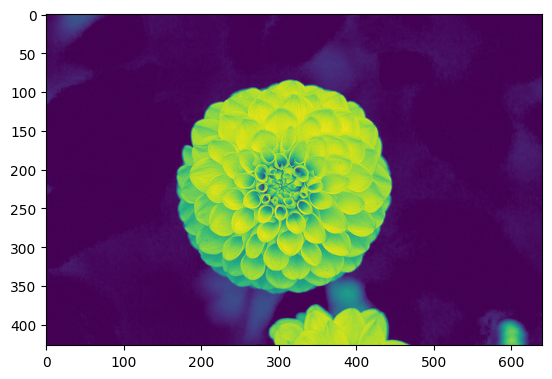

In [12]:
plt.imshow(sample_images[1][:,:,0])

In [13]:
sample_images = np.stack(sample_images)
sample_images.shape

(2, 427, 640, 3)

In [14]:
sample_images

array([[[[174, 201, 231],
         [174, 201, 231],
         [174, 201, 231],
         ...,
         [250, 251, 255],
         [250, 251, 255],
         [250, 251, 255]],

        [[172, 199, 229],
         [173, 200, 230],
         [173, 200, 230],
         ...,
         [251, 252, 255],
         [251, 252, 255],
         [251, 252, 255]],

        [[174, 201, 231],
         [174, 201, 231],
         [174, 201, 231],
         ...,
         [252, 253, 255],
         [252, 253, 255],
         [252, 253, 255]],

        ...,

        [[ 88,  80,   7],
         [147, 138,  69],
         [122, 116,  38],
         ...,
         [ 39,  42,  33],
         [  8,  14,   2],
         [  6,  12,   0]],

        [[122, 112,  41],
         [129, 120,  53],
         [118, 112,  36],
         ...,
         [  9,  12,   3],
         [  9,  15,   3],
         [ 16,  24,   9]],

        [[116, 103,  35],
         [104,  93,  31],
         [108, 102,  28],
         ...,
         [ 43,  49,  39],
        

In [15]:
sample_images = torch.FloatTensor(sample_images)
sample_images.shape

torch.Size([2, 427, 640, 3])

In [16]:
sample_images = sample_images/255
sample_images

tensor([[[[0.6824, 0.7882, 0.9059],
          [0.6824, 0.7882, 0.9059],
          [0.6824, 0.7882, 0.9059],
          ...,
          [0.9804, 0.9843, 1.0000],
          [0.9804, 0.9843, 1.0000],
          [0.9804, 0.9843, 1.0000]],

         [[0.6745, 0.7804, 0.8980],
          [0.6784, 0.7843, 0.9020],
          [0.6784, 0.7843, 0.9020],
          ...,
          [0.9843, 0.9882, 1.0000],
          [0.9843, 0.9882, 1.0000],
          [0.9843, 0.9882, 1.0000]],

         [[0.6824, 0.7882, 0.9059],
          [0.6824, 0.7882, 0.9059],
          [0.6824, 0.7882, 0.9059],
          ...,
          [0.9882, 0.9922, 1.0000],
          [0.9882, 0.9922, 1.0000],
          [0.9882, 0.9922, 1.0000]],

         ...,

         [[0.3451, 0.3137, 0.0275],
          [0.5765, 0.5412, 0.2706],
          [0.4784, 0.4549, 0.1490],
          ...,
          [0.1529, 0.1647, 0.1294],
          [0.0314, 0.0549, 0.0078],
          [0.0235, 0.0471, 0.0000]],

         [[0.4784, 0.4392, 0.1608],
          [0.5059

In [17]:
sample_images.shape

torch.Size([2, 427, 640, 3])

In [18]:
sample_images_permuted = sample_images.permute(0,3,1,2)
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

In [27]:
torch.prod(torch.tensor(sample_images_permuted.shape))

tensor(1639680)

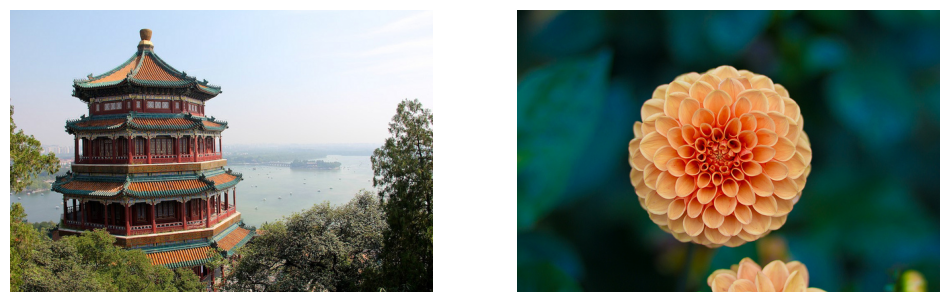

In [19]:
def plot_image(image_tensor):
  plt.imshow(image_tensor.permute(1,2,0))
  plt.axis('off')

plt.figure(figsize=(12,6))
for index, image_tensor in enumerate(sample_images_permuted):
  plt.subplot(1,2,index+1)
  plot_image(image_tensor)

In [20]:
427*640*3

819840

In [21]:
70*120*3

25200

In [22]:
cropper = T.CenterCrop(size=(70,120))
cropped_images = cropper(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

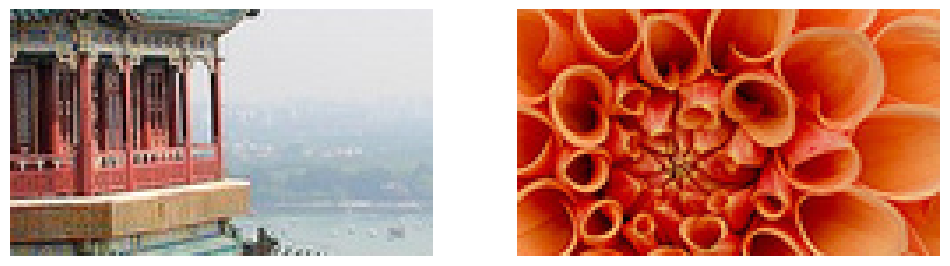

In [23]:
plt.figure(figsize=(12,6))
for index, image_tensor in enumerate(cropped_images):
  plt.subplot(1,2,index+1)
  plot_image(image_tensor)

In [24]:
conv_layer=nn.Conv2d(in_channels=3,out_channels=32,kernel_size=7)
output = conv_layer(cropped_images)
output.shape

torch.Size([2, 32, 64, 114])

In [25]:
conv_layer2=nn.Conv2d(in_channels=32,out_channels=64,kernel_size=5)
output2 = conv_layer2(output)
output2.shape

torch.Size([2, 64, 60, 110])

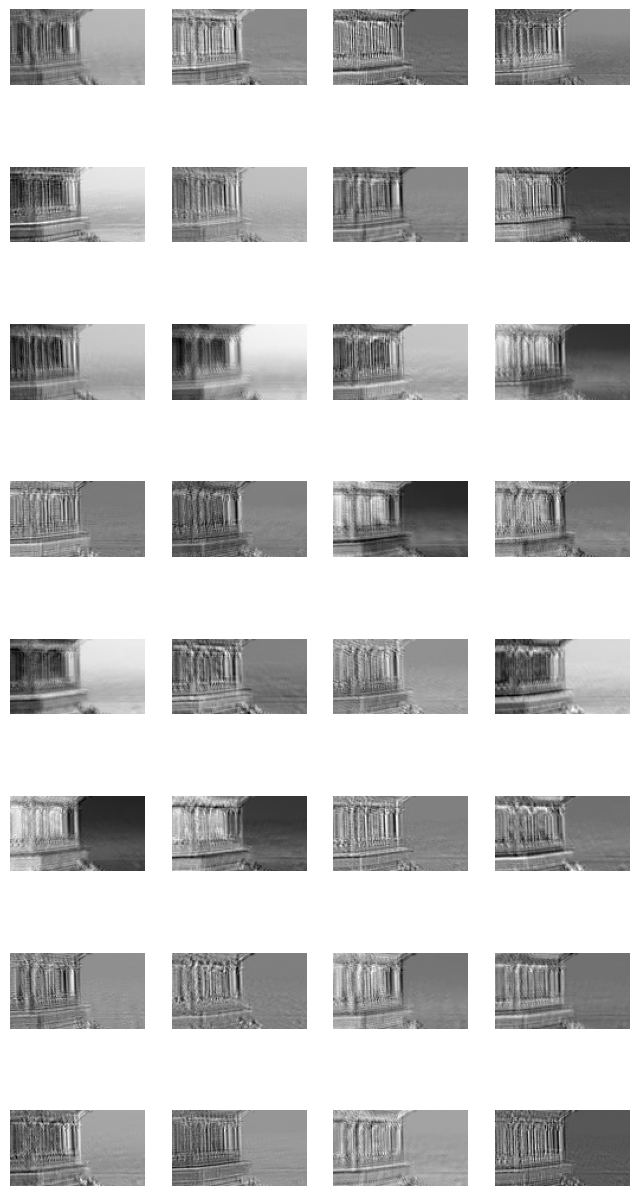

In [26]:
fig,axs = plt.subplots(8,4,figsize=(8,16))

for ind, ax in enumerate(axs.flat):
    ax.imshow(output[0][ind].detach(), cmap='gray')
    ax.axis('off')

In [32]:
model = nn.Sequential(
    nn.Conv2d(in_channels=3,out_channels=32,kernel_size=7), #(2,32,64,114)
    nn.ReLU(),
    nn.Conv2d(in_channels=32,out_channels=64,kernel_size=5), #(2,64,60,110)
    nn.ReLU(),
    nn.Conv2d(in_channels=64,out_channels=128,kernel_size=5), # (2,128,56,106)
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # (2,128,28,53)
    nn.Conv2d(in_channels=128,out_channels=256,kernel_size=5), #(2,256,24,49)
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), #(2,256,12,24)
    nn.Conv2d(in_channels=256,out_channels=512,kernel_size=3), # (2,512,10,22)
    nn.ReLU(),
    nn.Flatten(), #(2,512,10,22) --> (2,512,220) -->(2,112640)
    nn.Linear(in_features=112640,out_features=100),
    nn.ReLU(),
    nn.Linear(in_features=100,out_features=200),
    nn.ReLU(),
    nn.Linear(in_features=200,out_features=10)
)

output = model(cropped_images)
output.shape

torch.Size([2, 10])

In [33]:
output

tensor([[ 0.0694, -0.0132,  0.0582, -0.0535,  0.0638,  0.0536,  0.0648,  0.0215,
         -0.0108, -0.0183],
        [ 0.0697, -0.0129,  0.0580, -0.0534,  0.0638,  0.0536,  0.0648,  0.0214,
         -0.0110, -0.0185]], grad_fn=<AddmmBackward0>)